# Detección temprana de Diabetes

In [1]:
#Librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.model_selection import GridSearchCV, StratifiedKFold

In [2]:
#Carga de datos
data = pd.read_csv('C:/Users/SERGIO/Desktop/Ciencia Datos/Datos/diabetes.csv')
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
#Info general
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
#Traduciendo
data = data.rename(columns={
    'Pregnancies': 'Embarazos',
    'Glucose': 'Glucosa',
    'BloodPressure': 'Presión Arterial',
    'SkinThickness': 'Espesor Cutáneo',
    'Insulin': 'Insulina',
    'BMI': 'IMC',
    'DiabetesPedigreeFunction': 'Pedigrí de Función de Diabetes',
    'Age': 'Edad',
    'Outcome': 'Resultado',
})

data.columns

Index(['Embarazos', 'Glucosa', 'Presión Arterial', 'Espesor Cutáneo',
       'Insulina', 'IMC', 'Pedigrí de Función de Diabetes', 'Edad',
       'Resultado'],
      dtype='object')

## Análisis

In [5]:
#Resumen Estadístico
data.describe().round(2)

,Embarazos,Glucosa,Presión Arterial,Espesor Cutáneo,Insulina,IMC,Pedigrí de Función de Diabetes,Edad,Resultado
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


In [6]:
#Conteo de personas con y sin diabetes
data['Resultado'].value_counts()

Resultado
0    500
1    268
Name: count, dtype: int64

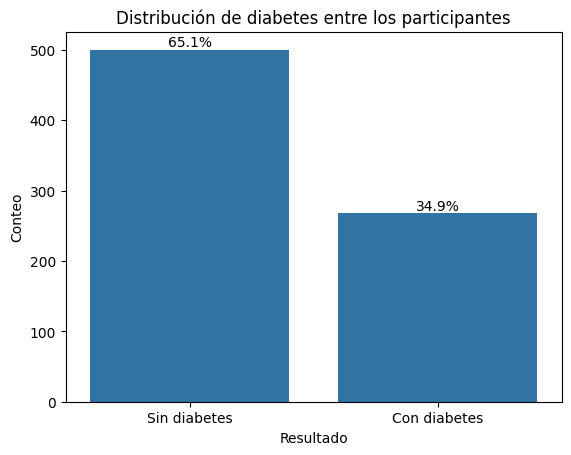

In [7]:
#Distribución de la variable objetivo
graf_outcome = sns.countplot(
    data = data,
    x='Resultado'
)

#Etiquetas
plt.title('Distribución de diabetes entre los participantes')
plt.xticks([0,1], ['Sin diabetes', 'Con diabetes'])
plt.ylabel('Conteo')

total = len(data)
for p in graf_outcome.patches:
    porcentaje = 100 * p.get_height() / total
    graf_outcome.annotate(
        f'{porcentaje:.1f}%',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )

C:\Users\SERGIO\AppData\Local\Temp\ipykernel_12148\3737772479.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\SERGIO\AppData\Local\Temp\ipykernel_12148\3737772479.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\SERGIO\AppData\Local\Temp\ipykernel_12148\3737772479.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\SERGIO\AppData\Local\Temp\ipykernel_12148\3737772479.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable t

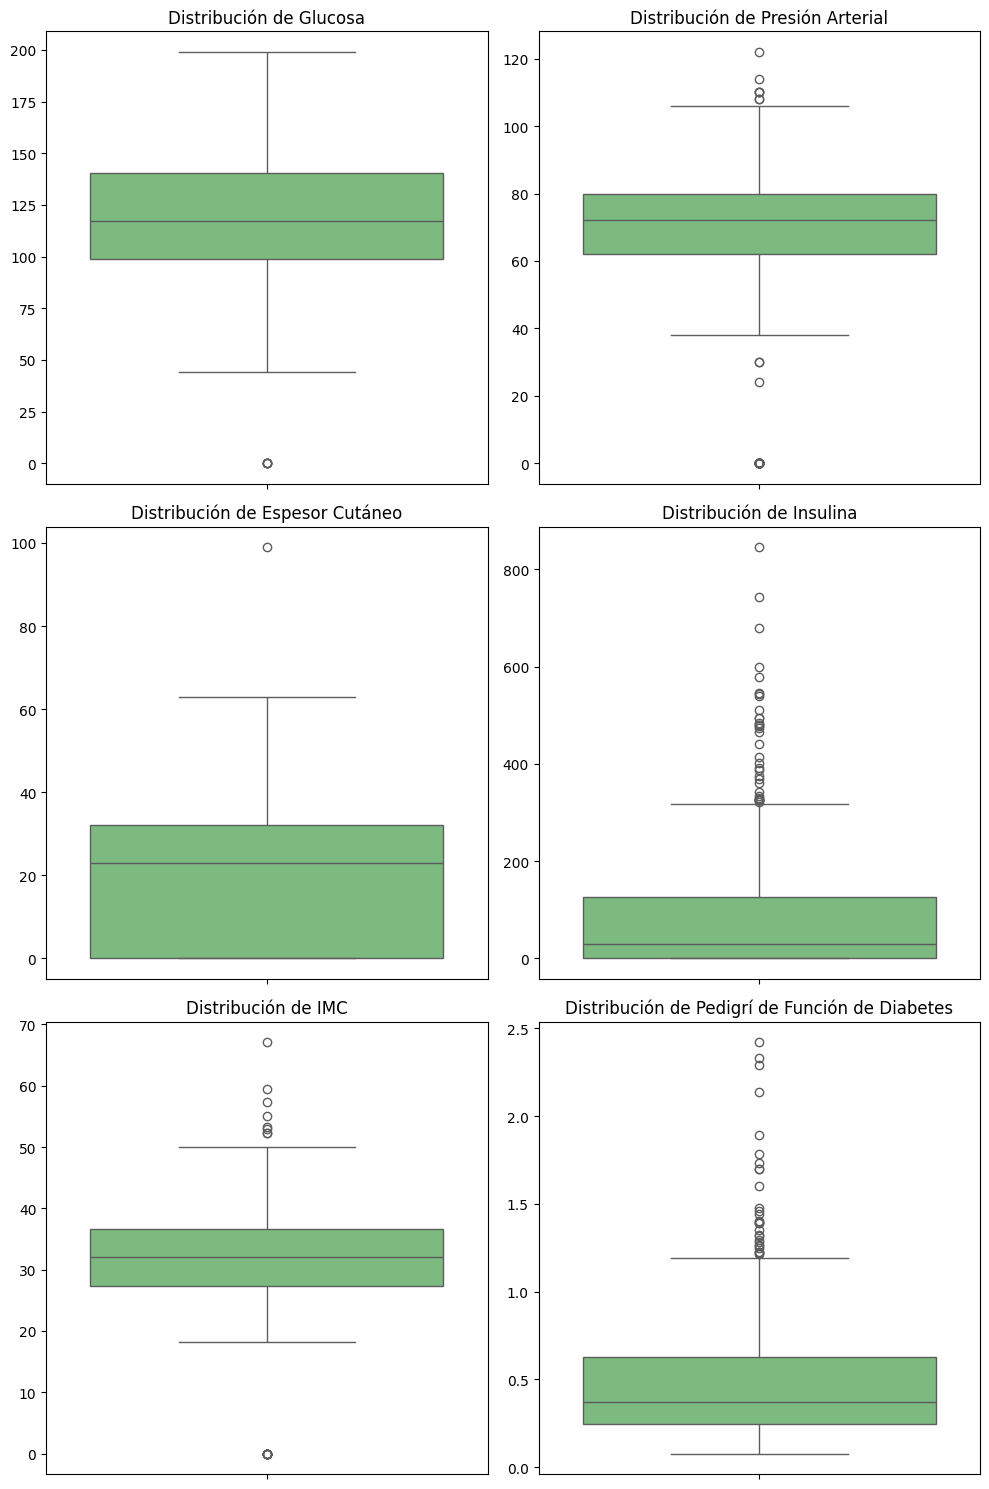

In [8]:
#Variables con datos erróneos
cols = data.columns[1:-2].tolist()

#Espacios para los boxplots
fig, axes = plt.subplots(3, 2, figsize=(10, 15))
axes = axes.flatten()

#Boxplots
for i, col in enumerate(cols):
    sns.boxplot(
        y = data[col],
        ax = axes[i],
        palette = 'Greens'
    )
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()


In [9]:
#Reemplazando ceros por NaN
#Seleccionando las columnas
cols_nan = data.columns[1:-3].tolist()

#Reemplazando ceros por NaN
data[cols_nan] = data[cols_nan].replace(0, np.nan)

#Revisión
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Embarazos                       768 non-null    int64  
 1   Glucosa                         763 non-null    float64
 2   Presión Arterial                733 non-null    float64
 3   Espesor Cutáneo                 541 non-null    float64
 4   Insulina                        394 non-null    float64
 5   IMC                             757 non-null    float64
 6   Pedigrí de Función de Diabetes  768 non-null    float64
 7   Edad                            768 non-null    int64  
 8   Resultado                       768 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.1 KB


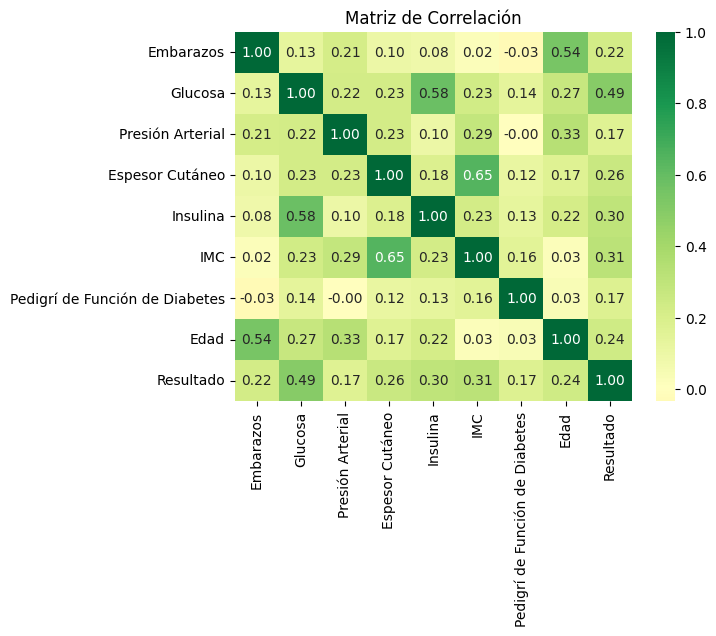

In [10]:
#Matriz de correlación de las variables
corr = data.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='RdYlGn',
    center=0,
    fmt='.2f'
)

plt.title('Matriz de Correlación')
plt.show()

## Modelado

### Split de variables

In [11]:
#Separando variables
X = data.iloc[:, :-1]
y = data['Resultado']

In [12]:
#Separación de conjuntos de entrenamiento y testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

### Preprocesamiento

In [13]:
#Obteniendo nombres de columnas a transformar
num_cols = X.columns
num_cols

Index(['Embarazos', 'Glucosa', 'Presión Arterial', 'Espesor Cutáneo',
       'Insulina', 'IMC', 'Pedigrí de Función de Diabetes', 'Edad'],
      dtype='object')

In [14]:
#Preprocesando
#Pipeline para transformaciones numéricas
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy = 'median')),
    ('scaler', StandardScaler())
])

preprocesador = ColumnTransformer(
    transformers = [
        ('num', num_pipeline, num_cols),
    ]
)

### Regresión Logística

In [15]:
#Modelo base
reg_log_1 = Pipeline(
    steps = [
        ('prep', preprocesador),
        ('model', LogisticRegression(random_state=42))
    ]
)

reg_log_1.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices

In [16]:
#Predicciones con datos de entrenamiento
y_pred_log_1_train = reg_log_1.predict(X_train)
y_prob_log_1_train = reg_log_1.predict_proba(X_train)[:, 1]

In [17]:
#Predicciones con datos de prueba
y_pred_log_1 = reg_log_1.predict(X_test)
y_prob_log_1 = reg_log_1.predict_proba(X_test)[:, 1]

In [18]:
#Matriz de confusión
print(f'Matriz de confusión en training:\n {confusion_matrix(y_train, y_pred_log_1_train)}\n')
print(f'Matriz de confusión en testing:\n {confusion_matrix(y_test, y_pred_log_1)}\n')


Matriz de confusión en training:
 [[362  38]
 [ 87 127]]

Matriz de confusión en testing:
 [[82 18]
 [27 27]]



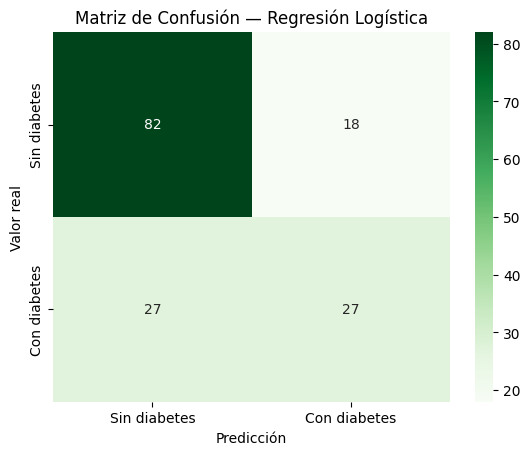

In [19]:
#Graficando la matriz de confusión en testing
sns.heatmap(
    confusion_matrix(y_test, y_pred_log_1),
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Sin diabetes', 'Con diabetes'],
    yticklabels=['Sin diabetes', 'Con diabetes']
)

plt.title('Matriz de Confusión — Regresión Logística')
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.show()

In [20]:
#Reporte de clasificación
print(f'Reporte de clasificación en training:\n {classification_report(y_train, y_pred_log_1_train)}\n')
print(f'Reporte de clasificación en testing:\n {classification_report(y_test, y_pred_log_1)}\n')

Reporte de clasificación en training:
               precision    recall  f1-score   support

           0       0.81      0.91      0.85       400
           1       0.77      0.59      0.67       214

    accuracy                           0.80       614
   macro avg       0.79      0.75      0.76       614
weighted avg       0.79      0.80      0.79       614


Reporte de clasificación en testing:
               precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154




In [21]:
#ROC Entrenamiento
fpr_train, tpr_train, thresholds = roc_curve(y_train, y_prob_log_1_train)
auc_train = auc(fpr_train, tpr_train)

#ROC Prueba
fpr_test, tpr_test, thresholds = roc_curve(y_test, y_prob_log_1)
auc_test = auc(fpr_test, tpr_test)

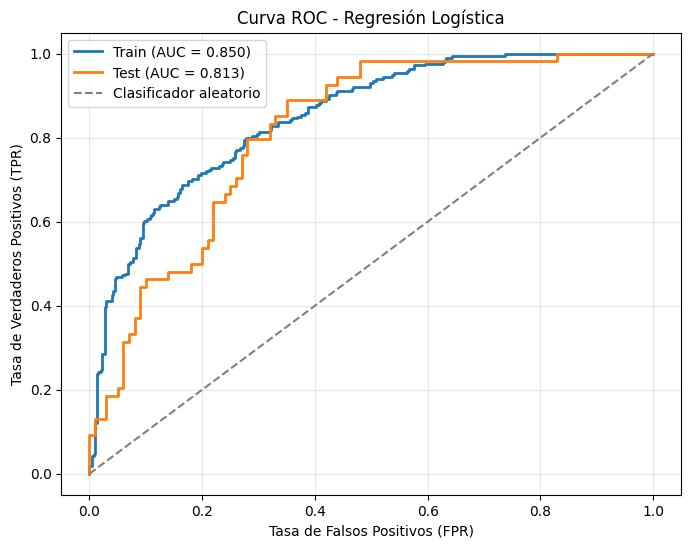

In [22]:
#Curva ROC
plt.figure(figsize=(8,6))

#Training
plt.plot(
    fpr_train,
    tpr_train,
    label=f'Train (AUC = {auc_train:.3f})',
    linewidth=2
)

#Testing
plt.plot(
    fpr_test,
    tpr_test,
    label=f'Test (AUC = {auc_test:.3f})',
    linewidth=2
)

plt.plot(
    [0,1],
    [0,1],
    '--',
    color='gray',
    label='Clasificador aleatorio'
)

plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - Regresión Logística')

plt.legend()
plt.grid(alpha=0.3)

plt.show()

### SVM

In [23]:
#Modelo Base
svc_1 = Pipeline(
    steps = [
        ('prep', preprocesador),
        ('model', SVC(probability = True, random_state = 42))
    ]
)

svc_1.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices

In [24]:
#Predicciones con datos de entrenamiento
y_pred_svc_1_train = svc_1.predict(X_train)
y_prob_svc_1_train = svc_1.predict_proba(X_train)[:, 1]

#Predicciones con datos de prueba
y_pred_svc_1 = svc_1.predict(X_test)
y_prob_svc_1 = svc_1.predict_proba(X_test)[:, 1]

In [25]:
#Matriz de confusión
print(f'Matriz de confusión en training:\n {confusion_matrix(y_train, y_pred_svc_1_train)}\n')
print(f'Matriz de confusión en testing:\n {confusion_matrix(y_test, y_pred_svc_1)}\n')

Matriz de confusión en training:
 [[372  28]
 [ 70 144]]

Matriz de confusión en testing:
 [[84 16]
 [24 30]]



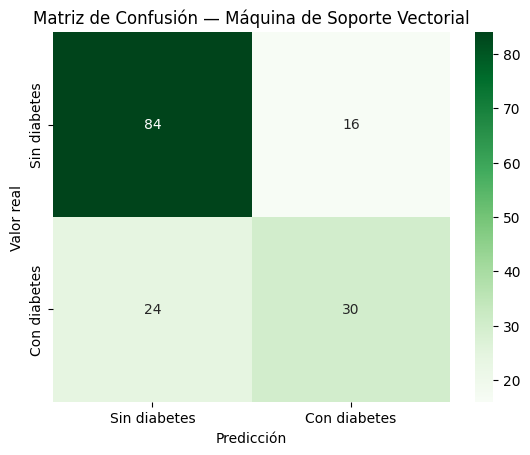

In [26]:
#Graficando la matriz de confusión en testing
sns.heatmap(
    confusion_matrix(y_test, y_pred_svc_1),
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Sin diabetes', 'Con diabetes'],
    yticklabels=['Sin diabetes', 'Con diabetes']
)

plt.title('Matriz de Confusión — Máquina de Soporte Vectorial')
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.show()

In [27]:
#Reporte de clasificación
print(f'Reporte de clasificación en training:\n {classification_report(y_train, y_pred_svc_1_train)}\n')
print(f'Reporte de clasificación en testing:\n {classification_report(y_test, y_pred_svc_1)}\n')

Reporte de clasificación en training:
               precision    recall  f1-score   support

           0       0.84      0.93      0.88       400
           1       0.84      0.67      0.75       214

    accuracy                           0.84       614
   macro avg       0.84      0.80      0.81       614
weighted avg       0.84      0.84      0.84       614


Reporte de clasificación en testing:
               precision    recall  f1-score   support

           0       0.78      0.84      0.81       100
           1       0.65      0.56      0.60        54

    accuracy                           0.74       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.74      0.73       154




In [28]:
#ROC Entrenamiento
fpr_train, tpr_train, thresholds = roc_curve(y_train, y_prob_svc_1_train)
auc_train = auc(fpr_train, tpr_train)

#ROC Prueba
fpr_test, tpr_test, thresholds = roc_curve(y_test, y_prob_svc_1)
auc_test = auc(fpr_test, tpr_test)


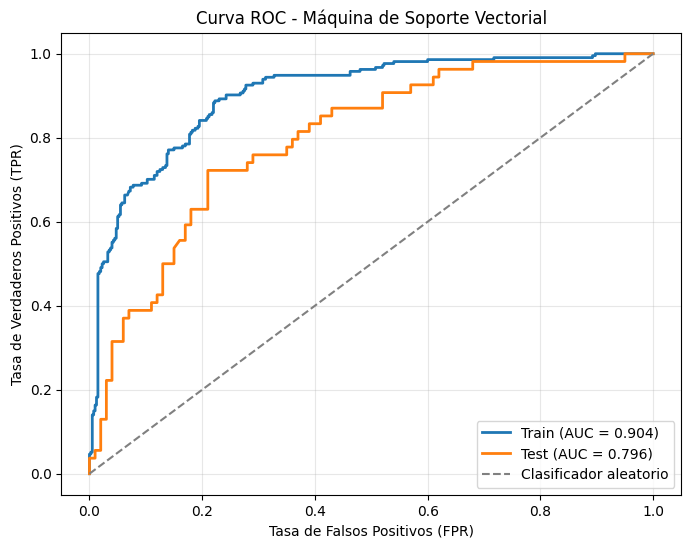

In [29]:
#Curva ROC
plt.figure(figsize=(8,6))

#Training
plt.plot(
    fpr_train,
    tpr_train,
    label=f'Train (AUC = {auc_train:.3f})',
    linewidth=2
)

#Testing
plt.plot(
    fpr_test,
    tpr_test,
    label=f'Test (AUC = {auc_test:.3f})',
    linewidth=2
)

plt.plot(
    [0,1],
    [0,1],
    '--',
    color='gray',
    label='Clasificador aleatorio'
)

plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - Máquina de Soporte Vectorial')

plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Árbol de Decisión

In [30]:
tree_1 = Pipeline(
    steps = [
        ('prep', preprocesador),
        ('model', DecisionTreeClassifier(random_state=42))
    ]
)

tree_1.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices

In [31]:
#Predicciones con datos de entrenamiento
y_pred_tree_1_train = tree_1.predict(X_train)
y_prob_tree_1_train = tree_1.predict_proba(X_train)[:, 1]

#Predicciones con datos de prueba
y_pred_tree_1 = tree_1.predict(X_test)
y_prob_tree_1 = tree_1.predict_proba(X_test)[:, 1]

In [32]:
#Matriz de confusión
print(f'Matriz de confusión en training:\n {confusion_matrix(y_train, y_pred_tree_1_train)}\n')
print(f'Matriz de confusión en testing:\n {confusion_matrix(y_test, y_pred_tree_1)}\n')

Matriz de confusión en training:
 [[400   0]
 [  0 214]]

Matriz de confusión en testing:
 [[79 21]
 [28 26]]



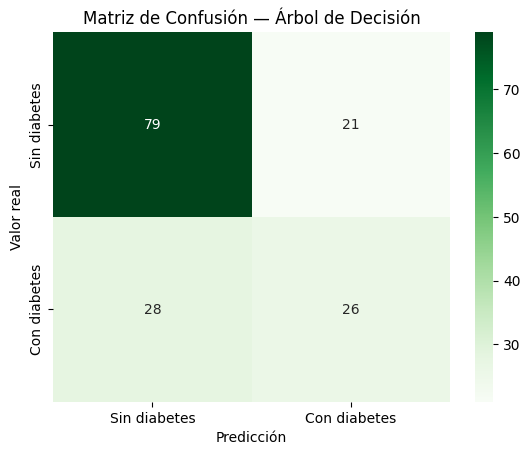

In [33]:
#Graficando la matriz de confusión en testing
sns.heatmap(
    confusion_matrix(y_test, y_pred_tree_1),
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Sin diabetes', 'Con diabetes'],
    yticklabels=['Sin diabetes', 'Con diabetes']
)

plt.title('Matriz de Confusión — Árbol de Decisión')
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.show()

In [34]:
#Reporte de clasificación
print(f'Reporte de clasificación en training:\n {classification_report(y_train, y_pred_tree_1_train)}\n')
print(f'Reporte de clasificación en testing:\n {classification_report(y_test, y_pred_tree_1)}\n')

Reporte de clasificación en training:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       400
           1       1.00      1.00      1.00       214

    accuracy                           1.00       614
   macro avg       1.00      1.00      1.00       614
weighted avg       1.00      1.00      1.00       614


Reporte de clasificación en testing:
               precision    recall  f1-score   support

           0       0.74      0.79      0.76       100
           1       0.55      0.48      0.51        54

    accuracy                           0.68       154
   macro avg       0.65      0.64      0.64       154
weighted avg       0.67      0.68      0.68       154




In [35]:
#ROC Entrenamiento
fpr_train, tpr_train, thresholds = roc_curve(y_train, y_prob_tree_1_train)
auc_train = auc(fpr_train, tpr_train)

#ROC Prueba
fpr_test, tpr_test, thresholds = roc_curve(y_test, y_prob_tree_1)
auc_test = auc(fpr_test, tpr_test)

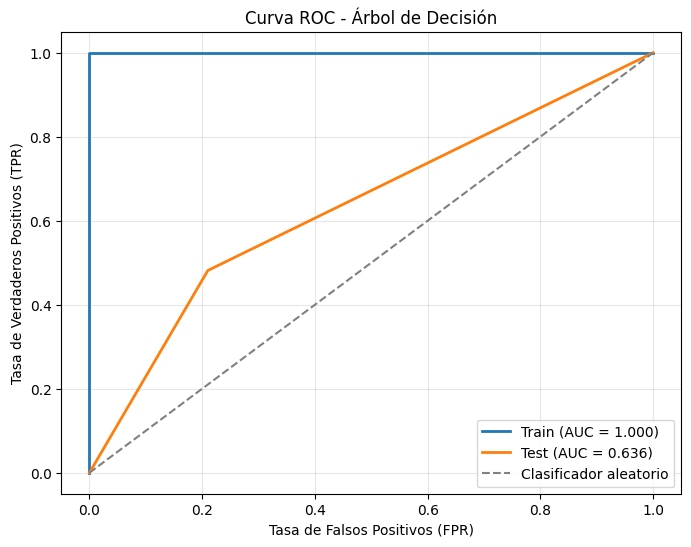

In [36]:
#Curva ROC
plt.figure(figsize=(8,6))

#Training
plt.plot(
    fpr_train,
    tpr_train,
    label=f'Train (AUC = {auc_train:.3f})',
    linewidth=2
)

#Testing
plt.plot(
    fpr_test,
    tpr_test,
    label=f'Test (AUC = {auc_test:.3f})',
    linewidth=2
)

plt.plot(
    [0,1],
    [0,1],
    '--',
    color='gray',
    label='Clasificador aleatorio'
)

plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - Árbol de Decisión')

plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Optimización de SVC

In [37]:
#Red de hiperparámetros
param_grid_svc = {
    'model__C': [0.1, 0.5, 1, 5, 10], #Penalización de errores
    'model__gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1], #Alcance de influencia de cada observación.
    'model__kernel': ['rbf', 'poly'], #Tipo de frontera de decisión.
    'model__class_weight': [None, 'balanced'] #Dar más peso a la calse minoritaria.
}

#Validación cruzada estratificada
cv_svc = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [38]:
#Búsqueda de hiperparámetros
grid_svc = GridSearchCV(
    estimator = svc_1,
    param_grid = param_grid_svc,
    scoring = 'f1',
    cv = cv_svc,
    n_jobs = -1,
    verbose = 1,
    return_train_score = True
)

#Entrenando el mejor modelo
grid_svc.fit(X_train, y_train)

Fitting 5 folds for each of 120 candidates, totalling 600 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.1, 0.5, ...], 'model__class_weight': [None, 'balanced'], 'model__gamma': ['scale', 'auto', ...], 'model__kernel': ['rbf', 'poly']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >

In [39]:
#Mejores hiperparámetros
print(f'Mejores hiperparámetros: {grid_svc.best_params_}\n')

#Mejor recall
print(f'Mejor f1 promedio en validación cruzada: {grid_svc.best_score_}')

Mejores hiperparámetros: {'model__C': 0.5, 'model__class_weight': 'balanced', 'model__gamma': 'scale', 'model__kernel': 'rbf'}

Mejor f1 promedio en validación cruzada: 0.6980770694884292


In [40]:
#Mejor modelo
mejor_svc = grid_svc.best_estimator_


In [41]:
#Predicciones con datos de entrenamiento
y_pred_mejor_svc_train = mejor_svc.predict(X_train)
y_prob_mejor_svc_train = mejor_svc.predict_proba(X_train)[:, 1]

#Predicciones con datos de prueba
y_pred_mejor_svc = mejor_svc.predict(X_test)
y_prob_mejor_svc = mejor_svc.predict_proba(X_test)[:, 1]

In [42]:
#Matriz de confusión
print(f'Matriz de confusión en training:\n {confusion_matrix(y_train, y_pred_mejor_svc_train)}\n')
print(f'Matriz de confusión en testing:\n {confusion_matrix(y_test, y_pred_mejor_svc)}\n')

Matriz de confusión en training:
 [[312  88]
 [ 39 175]]

Matriz de confusión en testing:
 [[71 29]
 [14 40]]



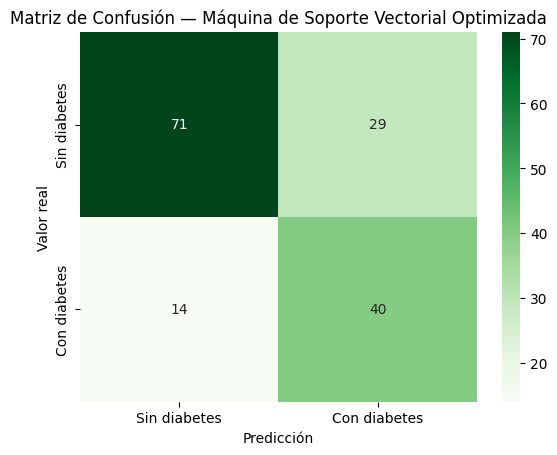

In [43]:
#Graficando la matriz de confusión en testing
sns.heatmap(
    confusion_matrix(y_test, y_pred_mejor_svc),
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Sin diabetes', 'Con diabetes'],
    yticklabels=['Sin diabetes', 'Con diabetes']
)

plt.title('Matriz de Confusión — Máquina de Soporte Vectorial Optimizada')
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.show()

In [44]:
#Reporte de clasificación
print(f'Reporte de clasificación en training:\n {classification_report(y_train, y_pred_mejor_svc_train)}\n')
print(f'Reporte de clasificación en testing:\n {classification_report(y_test, y_pred_mejor_svc)}\n')

Reporte de clasificación en training:
               precision    recall  f1-score   support

           0       0.89      0.78      0.83       400
           1       0.67      0.82      0.73       214

    accuracy                           0.79       614
   macro avg       0.78      0.80      0.78       614
weighted avg       0.81      0.79      0.80       614


Reporte de clasificación en testing:
               precision    recall  f1-score   support

           0       0.84      0.71      0.77       100
           1       0.58      0.74      0.65        54

    accuracy                           0.72       154
   macro avg       0.71      0.73      0.71       154
weighted avg       0.75      0.72      0.73       154




In [45]:
#ROC Entrenamiento
fpr_train, tpr_train, thresholds = roc_curve(y_train, y_prob_mejor_svc_train)
auc_train = auc(fpr_train, tpr_train)

#ROC Prueba
fpr_test, tpr_test, thresholds = roc_curve(y_test, y_prob_mejor_svc)
auc_test = auc(fpr_test, tpr_test)

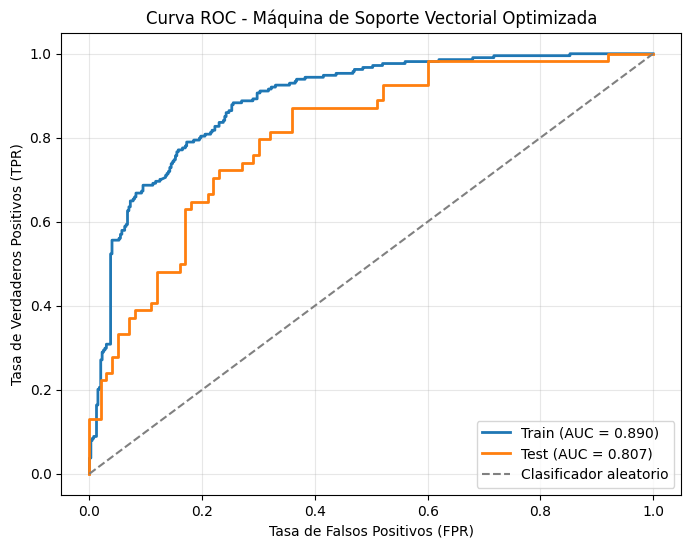

In [46]:
#Curva ROC
plt.figure(figsize=(8,6))

#Training
plt.plot(
    fpr_train,
    tpr_train,
    label=f'Train (AUC = {auc_train:.3f})',
    linewidth=2
)

#Testing
plt.plot(
    fpr_test,
    tpr_test,
    label=f'Test (AUC = {auc_test:.3f})',
    linewidth=2
)

plt.plot(
    [0,1],
    [0,1],
    '--',
    color='gray',
    label='Clasificador aleatorio'
)

plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - Máquina de Soporte Vectorial Optimizada')

plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Exportando modelo

In [47]:
#Librería
import joblib

#Exportando el modelo
joblib.dump(
    mejor_svc,
    'Modelo_deteccion_diabetes_svc.pkl'
)

['Modelo_deteccion_diabetes_svc.pkl']